In [1]:
!curl -L http://i.imgur.com/8o9DXSj.jpeg --output image.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 44094  100 44094    0     0   354k      0 --:--:-- --:--:-- --:--:--  354k


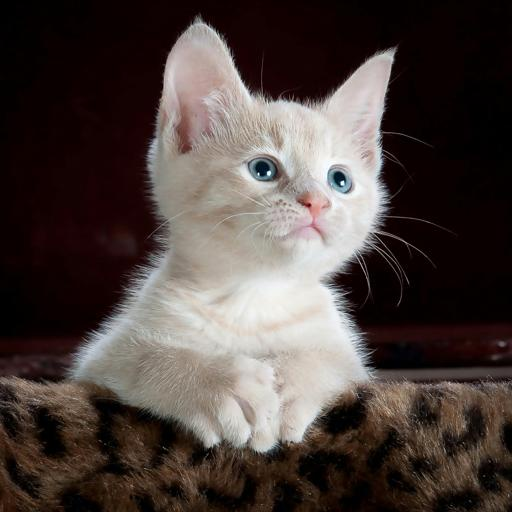

In [2]:
from PIL import Image
img = Image.open("image.jpg")
img

In [3]:
# Loading pre-trained SigLIP model
from transformers import AutoProcessor, SiglipVisionModel, SiglipVisionConfig
processor = AutoProcessor.from_pretrained("google/siglip-base-patch16-224")  #specify checkpoint
vision_model = SiglipVisionModel.from_pretrained("google/siglip-base-patch16-224", config=SiglipVisionConfig(vision_use_head = False))  # get trained model at this checkpoint
vision_model

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


SiglipVisionModel(
  (vision_model): SiglipVisionTransformer(
    (embeddings): SiglipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
      (position_embedding): Embedding(196, 768)
    )
    (encoder): SiglipEncoder(
      (layers): ModuleList(
        (0-11): 12 x SiglipEncoderLayer(
          (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attn): SiglipAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): SiglipMLP(
            (activation_fn): PytorchGELUTanh()
            (fc1): Linear(in_features=768, out_features=3072, 

In [4]:
import torch
from torch import nn
from torch.nn import functional as F
from dataclasses import dataclass
from torchvision import transforms

## Defining embeddings for our model

In [5]:
def preprocess_image(image, image_size=224):
  preprocess = transforms.Compose([
      transforms.Resize((image_size,image_size)),
      transforms.ToTensor(),
      transforms.Normalize(
          mean = [0.485, 0.456, 0.406],
          std = [0.229, 0.224, 0.225]
      )
  ])

  image_tensor = preprocess(image)
  image_tensor = image_tensor.unsqueeze(0)  #(3,224,224) -> (1,3,224,224) for batch dimension
  return image_tensor

image_tensor = preprocess_image(img)

In [6]:
embed_dim = 768
patch_size = 16
image_size = 224
num_patches = (image_size//patch_size)**2  # 224/16 = 14, 14**2 = 196

with torch.no_grad():
  patch_embedding = nn.Conv2d(in_channels=3, out_channels=embed_dim, kernel_size=patch_size, stride=patch_size)  # 224x224x3 = 14*14*768
  patches = patch_embedding(image_tensor)
print(patches.shape, num_patches)

torch.Size([1, 768, 14, 14]) 196


In [7]:
position_embedding = nn.Embedding(num_patches, embed_dim)
position_ids = torch.arange(num_patches).expand(1,-1)
position_ids.shape

torch.Size([1, 196])

In [8]:
embeddings = patches.flatten(start_dim=2, end_dim=-1)  # (1,768,14,14) -> (1,768,196)
embeddings = embeddings.transpose(1,2)  # (1,768,196) -> (1,196,768)
embeddings = embeddings + position_embedding(position_ids)  # will capture relative position of patches in each channel
print(embeddings.shape)

torch.Size([1, 196, 768])


In [9]:
import matplotlib.pyplot as plt

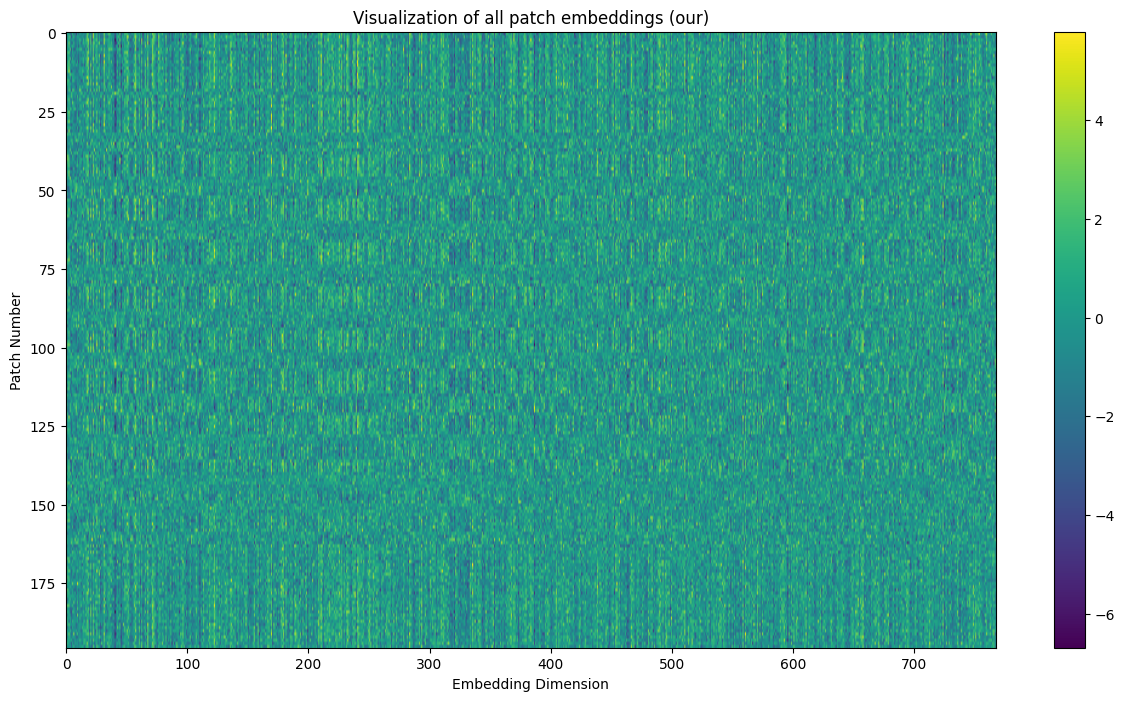

In [10]:
# Visulaize embeddings
patches_viz = embeddings[0].detach().numpy()  # [196,768]
plt.figure(figsize=(15,8))
plt.imshow(patches_viz, aspect="auto")
plt.colorbar()
plt.title("Visualization of all patch embeddings (our)")
plt.xlabel("Embedding Dimension")
plt.ylabel("Patch Number")
plt.show()

torch.Size([1, 196, 768])


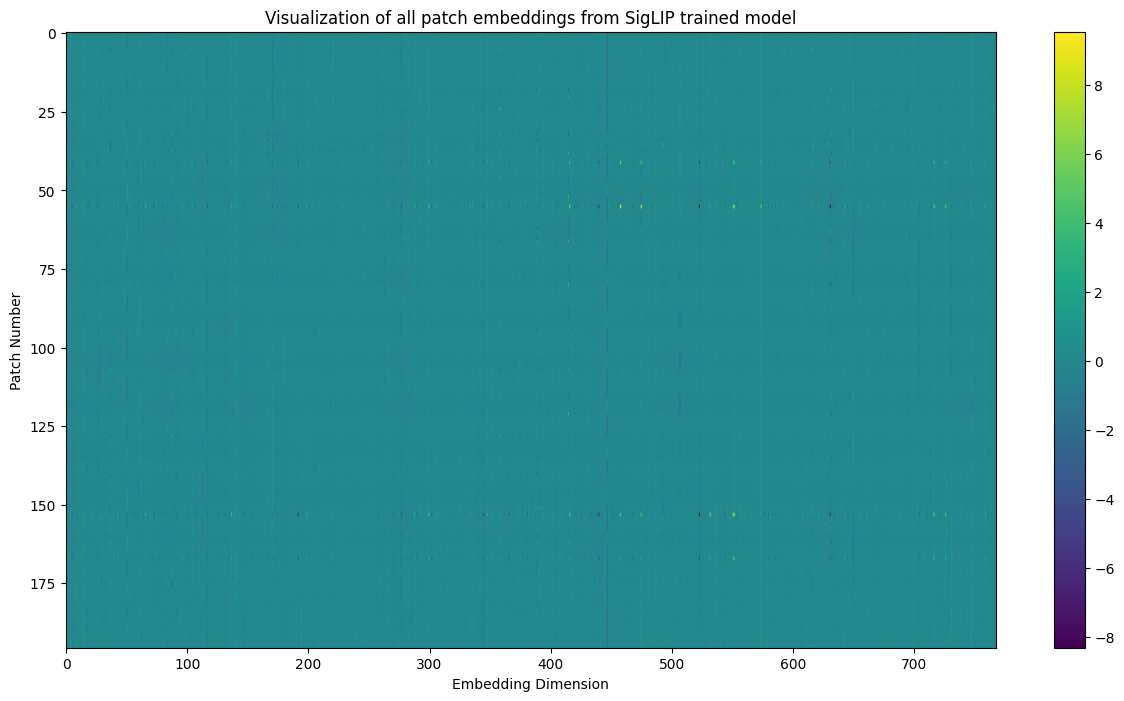

In [11]:
vision_model.eval()
inputs = processor(images=img, return_tensors="pt")
with torch.no_grad():
  patch_embeddings = vision_model.vision_model.embeddings(inputs.pixel_values)
print(patch_embeddings.shape)

# Visulaize SigLIP trained embeddings
patches_viz = patch_embeddings[0].detach().numpy()  # [196,768]
plt.figure(figsize=(15,8))
plt.imshow(patches_viz, aspect="auto")
plt.colorbar()
plt.title("Visualization of all patch embeddings from SigLIP trained model")
plt.xlabel("Embedding Dimension")
plt.ylabel("Patch Number")
plt.show()

In [12]:
@dataclass
class SiglipVisionConfig:
  num_channels: int = 3
  embed_dim: int = 768
  image_size: int = 224
  patch_size: int = 16

class SiglipVisionEmbeddings(nn.Module):
  def __init__(self, config: SiglipVisionConfig):
    super().__init__()
    self.config = config

    self.num_channels = config.num_channels
    self.embed_dim = config.embed_dim
    self.image_size = config.image_size
    self.patch_size = config.patch_size

    self.patch_embedding = nn.Conv2d(
        in_channels = self.num_channels,
        out_channels = self.embed_dim,
        kernel_size = self.patch_size,
        stride = self.patch_size,
        padding = "valid",
    )

    self.num_patches = (self.image_size//self.patch_size)**2
    self.num_positions = self.num_patches
    self.position_embedding = nn.Embedding(self.num_positions, self.embed_dim)
    self.register_buffer(
        "position_ids",
        torch.arange(self.num_positions).expand((1,-1)),
        persistent = False,
    )

  def forward(self, pixel_values: torch.FloatTensor) -> torch.Tensor:
    B,C,H,W = pixel_values.shape
    patch_embeds = self.patch_embedding(pixel_values)
    embeddings = patch_embeds.flatten(start_dim=2, end_dim=-1)
    embeddings = embeddings.transpose(1,2)
    embeddings = embeddings + self.position_embedding(self.position_ids)
    return embeddings

embd = SiglipVisionEmbeddings(SiglipVisionConfig())
embd(image_tensor).shape

torch.Size([1, 196, 768])

In [13]:
# Comparing our image embeddings with that of HuggingFace Siglip model
from transformers import SiglipVisionModel as HFSiglipVisionModel

our_state_dict = embd.state_dict()
hf_state_dict = {k.replace("vision_model.embeddings.", ""):v for k,v in vision_model.state_dict().items() if "vision_model.embeddings." in k}
our_state_dict.update(hf_state_dict) # Ensuring same weights for our embeddings as HF model
embd.load_state_dict(our_state_dict)

with torch.no_grad():
  our_output = embd(image_tensor)
  hf_output = vision_model.vision_model.embeddings(image_tensor)
  print("Max difference between our output and HF output: ", torch.max(torch.abs(our_output - hf_output)))

Max difference between our output and HF output:  tensor(0.)


## Defining the encoder architecture for our model

In [14]:
import math

class Head(nn.Module):
  """ A single head of the multi-head self-attention module """

  def __init__(self, n_in, n_head, context_length):
    super().__init__()
    self.head_size = n_head
    self.key = nn.Linear(n_in, n_head, bias=False)
    self.query = nn.Linear(n_in, n_head, bias=False)
    self.value = nn.Linear(n_in, n_head, bias=False)

  def forward(self,x):
    B,T,C = x.shape   # Get batch size, number of tokens, and embedding size
    k = self.key(x)   # key: information contained in the token
    q = self.query(x) # query: information the token is looking for
    v = self.value(x) # value: aggregated if there's a match
    wei = (q @ k.transpose(-2,-1)) * (1.0/math.sqrt(self.head_size)) # Normalized attnetion between query and key
    wei = F.softmax(wei, dim=-1)  # Raw attention scores to attention probability distribution
    out = wei @ v  # use attention weights to aggregate values
    return out


In [15]:
class MultiHeadAttention(nn.Module):
  """ Multi-head attention module
  Run all heads in parallel, then concatenate their output """

  def __init__(self, num_head, n_in, head_size, context_length):
    super().__init__()
    self.head_size = head_size
    self.num_head = num_head
    # The more heads we have, the more interesting features and relationships we can capture
    self.heads = [Head(n_in, head_size, context_length) for _ in range(num_head)]  # Each head can focus on different specific features, eg colors, textures
    self.proj = nn.Linear(n_in, n_in)  # Project output to the same dimension as input

  def forward(self,x):
    out = [h(x) for h in self.heads]
    out = torch.concat(out, -1)
    out = self.proj(out)
    return out


In [16]:
@dataclass
class SiglipVisionConfig:
  num_channels: int = 3
  image_size: int = 224
  patch_size: int = 16
  num_attention_heads: int = 12 # The more heads we have, the more interesting features and relationships we can capture.
  # Each head can focus on different specific features, eg colors, textures
  hidden_size: int = 768
  attention_dropout: int = 0.0

class SiglipAttention(nn.Module):
  def __init__(self, config: SiglipVisionConfig):
    super().__init__()
    self.config = config
    self.embed_dim = config.hidden_size
    self.num_heads = config.num_attention_heads
    self.dropout = config.attention_dropout

    self.k_proj = nn.Linear(self.embed_dim, self.embed_dim)
    self.q_proj = nn.Linear(self.embed_dim, self.embed_dim)
    self.v_proj = nn.Linear(self.embed_dim, self.embed_dim)
    self.out_proj = nn.Linear(self.embed_dim, self.embed_dim)

  def forward(self, hidden_states):
    # hidden states are the embeddings of the patches
    B,T,C = hidden_states.shape  # batch size, num_patches, embedding_size

    k_states = self.k_proj(hidden_states)
    q_states = self.q_proj(hidden_states)
    v_states = self.v_proj(hidden_states)

    # To process heads in parallel
    k_states = k_states.view(B, T, self.num_heads, C//self.num_heads).transpose(1,2)
    q_states = q_states.view(B, T, self.num_heads, C//self.num_heads).transpose(1,2)
    v_states = v_states.view(B, T, self.num_heads, C//self.num_heads).transpose(1,2)

    attn_weights = (q_states @ k_states.transpose(-2,-1)) * (1.0 / math.sqrt(k_states.size(-1)))
    attn_weights = F.softmax(attn_weights, dim=-1).to(q_states.dtype)
    attn_weights = F.dropout(attn_weights, p=self.dropout, training = self.training)
    attn_outs = attn_weights @ v_states
    attn_outs = attn_outs.transpose(1,2)
    attn_outs = attn_outs.reshape(B,T,C).contiguous()  # Ensuring the tensors are contiguous in memory allocation for efficient memory consumption
    attn_outs = self.out_proj(attn_outs)
    return attn_outs


In [17]:
batch_size = 1
num_patches = 196
embed_dim = 768

hidden_states = torch.randn(batch_size, num_patches, embed_dim)
config = SiglipVisionConfig(
    attention_dropout = 0.0,
    num_attention_heads = 12,
    hidden_size = 768
)

attention = SiglipAttention(config)
output = attention(hidden_states)

print(f"Input shape: {hidden_states.shape}")
print(f"Output shape: {output.shape}")
# They must have the same shape!

Input shape: torch.Size([1, 196, 768])
Output shape: torch.Size([1, 196, 768])


### Comparing our encoder implementation with HF

In [18]:
hf_state_dict = vision_model.vision_model.state_dict()
our_state_dict = attention.state_dict()

key_mapping = {
    # Mapping between our keys and HF keys for loading HF weights into our encoder
    'k_proj.weight' : 'encoder.layers.0.self_attn.k_proj.weight',
    'q_proj.weight' : 'encoder.layers.0.self_attn.q_proj.weight',
    'v_proj.weight' : 'encoder.layers.0.self_attn.v_proj.weight',
    'out_proj.weight' : 'encoder.layers.0.self_attn.out_proj.weight',
    'k_proj.bias' : 'encoder.layers.0.self_attn.k_proj.bias',
    'q_proj.bias' : 'encoder.layers.0.self_attn.q_proj.bias',
    'v_proj.bias' : 'encoder.layers.0.self_attn.v_proj.bias',
    'out_proj.bias' : 'encoder.layers.0.self_attn.out_proj.bias'
}

for our_key, hf_key in key_mapping.items():
  our_state_dict[our_key].copy_(hf_state_dict[hf_key])

attention.load_state_dict(our_state_dict)

with torch.no_grad():
  our_output = attention(hidden_states)
  hf_output = vision_model.vision_model.encoder.layers[0].self_attn(hidden_states)[0]
  max_diff = torch.max(torch.abs(our_output - hf_output))
  print(f"Max difference between input and output: {max_diff:.6f}")
  print((torch.isclose(our_output, hf_output, atol=1e-7)==0).sum())

Max difference between input and output: 0.000001
tensor(41)


### MLP layer for the Encoder block

In [19]:
@dataclass
class SiglipVisionConfig:
  num_channels: int = 3
  image_size: int = 224
  patch_size: int = 16
  num_attention_heads: int = 12
  hidden_size: int = 768
  attention_dropout: float = 0.0
  intermediate_size: int = 3072

class SiglipMLP(nn.Module):
  def __init__(self, config: SiglipVisionConfig):
    super().__init__()
    self.config = config
    self.fc1 = nn.Linear(config.hidden_size, config.intermediate_size)
    # By mapping the parameters to higher dimensions, the model can now learn more complex relations.
    self.fc2 = nn.Linear(config.intermediate_size, config.hidden_size)

  def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
    hidden_states = self.fc1(hidden_states)
    hidden_states = nn.functional.gelu(hidden_states, approximate='tanh')
    hidden_states = self.fc2(hidden_states)
    return hidden_states

mlp = SiglipMLP(SiglipVisionConfig(hidden_size=768, intermediate_size=3072))
mlp(torch.randn([1,196,768])).shape


torch.Size([1, 196, 768])

In [20]:
@dataclass
class SiglipVisionConfig:
  num_channels: int = 3
  image_size: int = 224
  patch_size: int = 16
  num_attention_heads: int = 12
  hidden_size: int = 768
  attention_dropout: float = 0.0
  intermediate_size: int = 3072
  layer_norm_eps: float = 1e-6

class SiglipVisionEmbeddings(nn.Module):
  def __init__(self, config: SiglipVisionConfig):
    super().__init__()
    self.config = config

    self.num_channels = config.num_channels
    self.image_size = config.image_size
    self.embed_dim = config.hidden_size
    self.patch_size = config.patch_size

    self.patch_embedding = nn.Conv2d(
        in_channels = self.num_channels,
        out_channels = self.embed_dim,
        kernel_size = self.patch_size,
        stride = self.patch_size,
        padding='valid',
    )

    self.num_patches = (self.image_size // self.patch_size) ** 2
    self.num_positions = self.num_patches
    self.position_embedding = nn.Embedding(self.num_positions, self.embed_dim) # Create embedding of size embed_dim for every i in range(num_positions)
    self.register_buffer(
        "position_ids",
        torch.arange(self.num_positions).expand((1,-1)),
        persistent = False,
    )

  def forward(self, pixel_values: torch.FloatTensor) -> torch.Tensor:
    B,C,H,W = pixel_values.shape
    patch_embeds = self.patch_embedding(pixel_values)
    embeddings = patch_embeds.flatten(start_dim = 2, end_dim = -1)
    embeddings = embeddings.transpose(1,2)
    embeddings = embeddings + self.position_embedding(self.position_ids)
    return embeddings


In [21]:
class SiglipEncoderLayer(nn.Module):
  def __init__(self, config = SiglipVisionConfig):
    super().__init__()
    self.embed_dim = config.hidden_size
    self.self_attn = SiglipAttention(config)
    self.layer_norm1 = nn.LayerNorm(self.embed_dim, eps = config.layer_norm_eps)
    self.mlp = SiglipMLP(config)
    self.layer_norm2 = nn.LayerNorm(self.embed_dim, eps = config.layer_norm_eps)

  def forward(self, hidden_states):
    residual = hidden_states
    hidden_states = self.layer_norm1(hidden_states)
    hidden_states = self.self_attn(hidden_states)
    hidden_states = residual + hidden_states

    residual = hidden_states
    hidden_states = self.layer_norm2(hidden_states)
    hidden_states = self.mlp(hidden_states)
    hidden_states = residual + hidden_states
    return hidden_states

encoder_layer = SiglipEncoderLayer(SiglipVisionConfig(hidden_size=768, intermediate_size=3072))
encoder_layer(torch.randn(1,196,768)).shape

torch.Size([1, 196, 768])

In [22]:
@dataclass
class SiglipVisionConfig:
  num_hidden_layers: int = 12  # same as original layer
  num_channels: int = 3
  image_size: int = 224
  patch_size: int = 16
  num_attention_heads: int = 12
  hidden_size: int = 768
  intermediate_size: int = 3072
  layer_norm_eps: float = 1e-6
  attention_dropout: float = 0.0

class SiglipEncoder(nn.Module):
  def __init__(self, config: SiglipVisionConfig):
    super().__init__()
    self.config = config
    self.layers = nn.ModuleList([SiglipEncoderLayer(config) for _ in range(config.num_hidden_layers)])

  def forward(self, hidden_states):
    for layer in self.layers:
      hidden_states = layer(hidden_states)
    return hidden_states


encoder = SiglipEncoder(SiglipVisionConfig(hidden_size=768, intermediate_size=3072))
encoder(torch.randn(1, 196, 768)).shape

torch.Size([1, 196, 768])

In [23]:
class SiglipVisionTransformer(nn.Module):
  def __init__(self, config: SiglipVisionConfig):
    super().__init__()
    self.config = config
    self.embeddings = SiglipVisionEmbeddings(config)
    self.encoder = SiglipEncoder(config)
    self.post_layernorm = nn.LayerNorm(config.hidden_size, eps = config.layer_norm_eps)

  def forward(self, pixel_values):
    hidden_states = self.embeddings(pixel_values)
    last_hidden_state = self.encoder(hidden_states)
    last_hidden_state = self.post_layernorm(last_hidden_state)
    return last_hidden_state

siglip = SiglipVisionTransformer(SiglipVisionConfig(hidden_size=768, intermediate_size = 3072))
siglip(image_tensor).shape

torch.Size([1, 196, 768])

In [24]:
class SiglipVisionModel(nn.Module):
  def __init__(self, config: SiglipVisionConfig):
    super().__init__()
    self.config = config
    self.vision_model = SiglipVisionTransformer(config)

  def forward(self, pixel_values):
    return self.vision_model(pixel_values)

siglip = SiglipVisionModel(SiglipVisionConfig(hidden_size = 768, intermediate_size = 3072))
siglip(image_tensor).shape

torch.Size([1, 196, 768])

In [25]:
hf_state_dict = vision_model.state_dict()
our_state_dict = siglip.state_dict()
our_state_dict.update(hf_state_dict)
siglip.load_state_dict(hf_state_dict)

<All keys matched successfully>

# Using these vision embeddings for classification

# Load data

In [26]:
from torchvision.datasets import CIFAR10
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler
import numpy as np

In [27]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # based on imagenet statistics
])

In [28]:
# Load data
train_dataset = CIFAR10(root='./data', train=True, transform=transform, download=True)
test_dataset = CIFAR10(root='./data', train=False, transform=transform, download=True)

In [29]:
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
train_loader

In [30]:
import torch.optim as optim
import numpy as np

In [31]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [33]:
import torch.nn as nn

class SigLIPClassifier(nn.Module):
    def __init__(self, vision_model, num_classes):
        super().__init__()
        self.vision = vision_model
        self.head = nn.Linear(self.vision.config.hidden_size, 1024)
        self.out = nn.Linear(1024, num_classes)

    def forward(self, pixel_values):
        embeddings = self.vision(pixel_values)  # returns tensor
        pooled = embeddings.mean(dim = 1)
        head = self.head(pooled)
        out = self.out(head)
        return out

# Instantiate
model = SigLIPClassifier(siglip, num_classes=10).to(device)


In [34]:
for param in model.vision.parameters():
    param.requires_grad = False
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [35]:
for name, param in model.named_parameters():
    print(f"{name}: requires_grad = {param.requires_grad}")

vision.vision_model.embeddings.patch_embedding.weight: requires_grad = False
vision.vision_model.embeddings.patch_embedding.bias: requires_grad = False
vision.vision_model.embeddings.position_embedding.weight: requires_grad = False
vision.vision_model.encoder.layers.0.self_attn.k_proj.weight: requires_grad = False
vision.vision_model.encoder.layers.0.self_attn.k_proj.bias: requires_grad = False
vision.vision_model.encoder.layers.0.self_attn.q_proj.weight: requires_grad = False
vision.vision_model.encoder.layers.0.self_attn.q_proj.bias: requires_grad = False
vision.vision_model.encoder.layers.0.self_attn.v_proj.weight: requires_grad = False
vision.vision_model.encoder.layers.0.self_attn.v_proj.bias: requires_grad = False
vision.vision_model.encoder.layers.0.self_attn.out_proj.weight: requires_grad = False
vision.vision_model.encoder.layers.0.self_attn.out_proj.bias: requires_grad = False
vision.vision_model.encoder.layers.0.layer_norm1.weight: requires_grad = False
vision.vision_model.e

In [36]:
num_epochs = 10#NUM_EPOCHS

for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0
  for images,labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()

    logits = model(images)
    loss = criterion(logits,labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

  print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/10], Loss: 1.0283
Epoch [2/10], Loss: 0.8833
Epoch [3/10], Loss: 0.8487
Epoch [4/10], Loss: 0.8390
Epoch [5/10], Loss: 0.8174
Epoch [6/10], Loss: 0.8106
Epoch [7/10], Loss: 0.8038
Epoch [8/10], Loss: 0.8035
Epoch [9/10], Loss: 0.7990
Epoch [10/10], Loss: 0.7974


In [37]:
# Evaluation
model.eval()
total, correct = 0, 0

with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs,1)
    total += labels.size(0)
    correct += (labels==predicted).sum().item()

accuracy = 100*correct/total
print(f"Accuracy: {accuracy: .2f}%")

Accuracy:  68.49%
